In [1]:
"""
FinDER (FinanceRAG) retrieval evaluation harness — modular splitter x retriever sweep.
 
Loads FinDER corpus/queries/qrels from LOCAL files (Kaggle export), tries
multiple splitter types x chunk configs x retriever backends, and scores
every combination at multiple k values with Recall@k / NDCG@k.
 
Usage:
    pip install sentence-transformers datasets scikit-learn numpy pandas \
        langchain-text-splitters faiss-cpu chromadb rank_bm25 --break-system-packages
    python finder_splitter_eval.py
 
Not every dependency is required — retrievers/splitters with missing
libraries are skipped automatically (see the try/except ImportError guards).
"""
 
import math
from dataclasses import dataclass
try:
    from .retrievers import get_retriever
    from .splitters import get_splitter
except ImportError:
    from Retrievers import get_retriever   # falls back to a flat, non-package import
    from Splitters import get_splitter

import numpy as np
import pandas as pd
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sentence_transformers import CrossEncoder

"""The orchestrator. Knows the SHAPE of the sweep (splitter x config x
retriever x k) but not the concrete implementations — those are looked up
through the factories, so this file doesn't change when a new splitter or
retriever is added elsewhere."""

import numpy as np
import pandas as pd

D:\conda_envs\finder\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\conda_envs\finder\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
import math
 
 
def dcg(rels: list[int]) -> float:
    return sum(r / math.log2(i + 2) for i, r in enumerate(rels))
 
 
def ndcg_at_k(retrieved_doc_ids: list[str], relevant_doc_ids: set[str], k: int) -> float:
    rels = [1 if d in relevant_doc_ids else 0 for d in retrieved_doc_ids[:k]]
    ideal_dcg = dcg(sorted(rels, reverse=True))
    return dcg(rels) / ideal_dcg if ideal_dcg > 0 else 0.0
 
 
def recall_at_k(retrieved_doc_ids: list[str], relevant_doc_ids: set[str], k: int) -> float:
    if not relevant_doc_ids:
        return 0.0
    hit = len(set(retrieved_doc_ids[:k]) & relevant_doc_ids)
    return hit / len(relevant_doc_ids)
    

In [3]:
"""Config objects — the single place that describes an experiment."""
 
from dataclasses import dataclass, field
 
 
@dataclass(frozen=True)
class SplitterSpec:
    """One splitter type + one (chunk_size, overlap) config to try."""
    name: str          # key into the splitter factory registry
    chunk_size: int
    overlap: int
 
 
@dataclass(frozen=True)
class DataConfig:
    corpus_path: str
    queries_path: str
    qrels_path: str
    qrels_cols: tuple[str, str, str] = ("query_id", "corpus_id", "score")
    qrels_delimiter: str = "\t"

@dataclass(frozen=True)
class ExperimentConfig:
    data: DataConfig
    embed_model: str
    splitter_specs: list[SplitterSpec]
    retriever_names: list[str]           # keys into the retriever factory registry
    k_values: list[int] = field(default_factory=lambda: [ 5, 10, 20, 30, 40, 50])
    max_queries: int | None = 200
    max_corpus_docs: int | None = None
    output_csv: str = "../results/finder_hybridRetriever_results.csv"
    reranker_name: str | None = None            # e.g. "cross_encoder"; None = no reranking stage
    reranker_model: str = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    rerank_pool: int = 50                        # candidates pulled from the retriever before reranking
    @property
    def max_k(self) -> int:
        return max(self.k_values)


 

In [4]:

class FinRAGDataLoader:
    def __init__(self, cfg: DataConfig):
        self.cfg = cfg
 
    def load(self):
        corpus_ds = load_dataset("json", data_files=self.cfg.corpus_path, split="train")
        queries_ds = load_dataset("json", data_files=self.cfg.queries_path, split="train")
        try:
            qrels_ds = load_dataset("csv", data_files=self.cfg.qrels_path,
                                     delimiter=self.cfg.qrels_delimiter, split="train")
        except Exception as e:
            raise SystemExit(f"Could not load qrels file '{self.cfg.qrels_path}': {e}")
        return list(corpus_ds), list(queries_ds), qrels_ds
 
    def build_relevant_map(self, qrels_ds, query_ids: set[str]) -> dict[str, set[str]]:
        qcol, dcol, scol = self.cfg.qrels_cols
        relevant: dict[str, set[str]] = {}
        for row in qrels_ds:
            qid = str(row[qcol])
            if qid not in query_ids:
                continue
            if row.get(scol, 1) and int(row[scol]) > 0:
                relevant.setdefault(qid, set()).add(str(row[dcol]))
        return relevant
        

In [5]:



class Pipeline:
    def __init__(self, cfg: ExperimentConfig):
        self.cfg = cfg
        self.loader = FinRAGDataLoader(cfg.data)
        self._model = SentenceTransformer(cfg.embed_model)
        # Load once, not per (splitter, retriever) combo — a cross-encoder is
        # comparatively expensive to load and is independent of chunking/retrieval choice.
        self.reranker = None

    def _build_chunks(self, corpus_rows, splitter_name, chunk_size, overlap):
        splitter = get_splitter(splitter_name, chunk_size, overlap)   # may raise ImportError; caller decides
        doc_ids, texts = [], []
        for row in corpus_rows:
            title = (row.get("title") or "").strip()
            body = row.get("text") or ""
            full_text = f"{title}\n{body}" if title else body
            for piece in splitter.split(full_text):
                if piece and piece.strip():
                    doc_ids.append(str(row["_id"]))
                    texts.append(piece)
        return doc_ids, texts

    def run(self) -> pd.DataFrame:
        cfg = self.cfg
        corpus_rows, queries_rows, qrels_ds = self.loader.load()
        if cfg.max_corpus_docs:
            corpus_rows = corpus_rows[:cfg.max_corpus_docs]
        if cfg.max_queries:
            queries_rows = queries_rows[:cfg.max_queries]

        query_ids = {str(r["_id"]) for r in queries_rows}
        relevant = self.loader.build_relevant_map(qrels_ds, query_ids)
        print(f"Corpus docs: {len(corpus_rows)} | Queries: {len(queries_rows)} "
              f"| Queries with qrels: {len(relevant)}")

        query_texts = [r["text"] for r in queries_rows]
        query_vecs = self._model.encode(query_texts, normalize_embeddings=True,batch_size=64, show_progress_bar=True )

        results = []
        for spec in cfg.splitter_specs:
            try:
                chunk_doc_ids, chunk_texts = self._build_chunks(corpus_rows, spec.name, spec.chunk_size, spec.overlap)
            except ImportError as e:
                print(f"Skipping splitter '{spec.name}': missing dependency ({e})")
                continue

            chunk_vecs = self._model.encode(chunk_texts)

            for retriever_name in cfg.retriever_names:
                try:
                    retriever = get_retriever(retriever_name)
                except KeyError as e:
                    print(e)
                    continue
                # If reranking, pull a wider candidate pool from the retriever first —
                # the retriever's own ranking within that pool no longer matters much,
                # since the reranker will reorder it before we score at each k.
                pool_k = max(cfg.max_k, cfg.rerank_pool) if self.reranker else cfg.max_k
                try:
                    retriever.fit(chunk_texts, chunk_vecs)
                    pool_idx = retriever.query(query_texts, query_vecs, pool_k)
                except ImportError as e:
                    print(f"Skipping retriever '{retriever_name}': missing dependency ({e})")
                    continue

                per_k_recall = {k: [] for k in cfg.k_values}
                per_k_ndcg = {k: [] for k in cfg.k_values}
                for qi, row in enumerate(queries_rows):
                    rel_docs = relevant.get(str(row["_id"]))
                    if not rel_docs:
                        continue
                    candidate_idx = list(pool_idx[qi])
                    if self.reranker:
                        candidate_texts = [chunk_texts[i] for i in candidate_idx]
                        order = self.reranker.rerank(row["text"], candidate_texts)
                        candidate_idx = [candidate_idx[o] for o in order]
                    retrieved = [chunk_doc_ids[i] for i in candidate_idx]
                    for k in cfg.k_values:
                        per_k_recall[k].append(recall_at_k(retrieved, rel_docs, k))
                        per_k_ndcg[k].append(ndcg_at_k(retrieved, rel_docs, k))

                for k in cfg.k_values:
                    results.append({
                        "splitter": spec.name, "chunk_size": spec.chunk_size, "overlap": spec.overlap,
                        "retriever": retriever_name,
                        "reranker": cfg.reranker_name or "none",
                        "k": k,
                        "n_chunks": len(chunk_texts),
                        "n_queries_scored": len(per_k_recall[k]),
                        "recall": np.mean(per_k_recall[k]) if per_k_recall[k] else float("nan"),
                        "ndcg": np.mean(per_k_ndcg[k]) if per_k_ndcg[k] else float("nan"),
                    })

        df = pd.DataFrame(results).sort_values(["k", "ndcg"], ascending=[True, False])
        df.to_csv(cfg.output_csv, index=False)
        return df

In [6]:
CONFIG = ExperimentConfig(
    data=DataConfig(
        corpus_path="../finrag_data/finder_corpus.jsonl/corpus.jsonl",
        queries_path="../finrag_data/finder_queries.jsonl/queries.jsonl",
        qrels_path="../finrag_data/FinDER_qrels.tsv",
    ),
    embed_model="sentence-transformers/all-MiniLM-L6-v2",
    splitter_specs=[
        SplitterSpec("char", 256, 40),
        SplitterSpec("char", 512, 0),
        SplitterSpec("recursive_char", 256, 64),
        SplitterSpec("token", 128, 20),
    ],
    retriever_names=["cosine_numpy", "faiss_flat", "bm25", "hybrid_rrf"],
    k_values=[ 5, 10, 20, 30, 40, 50],
    max_queries=200,
    max_corpus_docs=None,
    # Optional second stage: reranks the top `rerank_pool` candidates from
    # each retriever above with a cross-encoder before scoring at each k.
    # Set to None to skip reranking entirely and go back to raw retriever output.
    reranker_name="cross_encoder",
    reranker_model="cross-encoder/ms-marco-MiniLM-L-6-v2",
    rerank_pool=50,
)

In [7]:
if __name__ == "__main__":
    df = Pipeline(CONFIG).run()
    print(df.to_string(index=False))
    

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3664.92it/s]


Corpus docs: 13867 | Queries: 200 | Queries with qrels: 61


Batches: 100%|██████████| 4/4 [00:01<00:00,  3.66it/s]


      splitter  chunk_size  overlap    retriever      reranker  k  n_chunks  n_queries_scored   recall     ndcg
         token         128       20 cosine_numpy cross_encoder  5     21450                61 0.345082 0.281617
         token         128       20   faiss_flat cross_encoder  5     21450                61 0.345082 0.281617
          char         512        0 cosine_numpy cross_encoder  5     23266                61 0.312295 0.271096
          char         512        0   faiss_flat cross_encoder  5     23266                61 0.312295 0.271096
          char         256       40 cosine_numpy cross_encoder  5     42451                61 0.317213 0.269119
          char         256       40   faiss_flat cross_encoder  5     42451                61 0.317213 0.269119
recursive_char         256       64 cosine_numpy cross_encoder  5     53567                61 0.293443 0.253922
          char         256       40   hybrid_rrf cross_encoder  5     42451                61 0.301639 0

In [8]:
best = ( df.sort_values(["ndcg", "recall"], ascending=[True, True]).head(10) )
print(df.to_string(index=False))


      splitter  chunk_size  overlap    retriever      reranker  k  n_chunks  n_queries_scored   recall     ndcg
         token         128       20 cosine_numpy cross_encoder  5     21450                61 0.345082 0.281617
         token         128       20   faiss_flat cross_encoder  5     21450                61 0.345082 0.281617
          char         512        0 cosine_numpy cross_encoder  5     23266                61 0.312295 0.271096
          char         512        0   faiss_flat cross_encoder  5     23266                61 0.312295 0.271096
          char         256       40 cosine_numpy cross_encoder  5     42451                61 0.317213 0.269119
          char         256       40   faiss_flat cross_encoder  5     42451                61 0.317213 0.269119
recursive_char         256       64 cosine_numpy cross_encoder  5     53567                61 0.293443 0.253922
          char         256       40   hybrid_rrf cross_encoder  5     42451                61 0.301639 0

In [9]:
best = df.loc[df["ndcg"].idxmax()]

print(best.to_string())

splitter                     char
chunk_size                    512
overlap                         0
retriever            cosine_numpy
reranker            cross_encoder
k                              40
n_chunks                    23266
n_queries_scored               61
recall                   0.653005
ndcg                     0.360018


In [10]:
for k in CONFIG.k_values:
    best_ndcg = df.loc[df.groupby("k")["ndcg"].idxmax()]
    best_recall = df.loc[df.groupby("k")["recall"].idxmax()]

In [11]:
print( best_ndcg)

   splitter  chunk_size  overlap     retriever       reranker   k  n_chunks  \
72    token         128       20  cosine_numpy  cross_encoder   5     21450   
25     char         512        0  cosine_numpy  cross_encoder  10     23266   
26     char         512        0  cosine_numpy  cross_encoder  20     23266   
27     char         512        0  cosine_numpy  cross_encoder  30     23266   
28     char         512        0  cosine_numpy  cross_encoder  40     23266   
29     char         512        0  cosine_numpy  cross_encoder  50     23266   

    n_queries_scored    recall      ndcg  
72                61  0.345082  0.281617  
25                61  0.464481  0.332685  
26                61  0.542350  0.346699  
27                61  0.607923  0.355308  
28                61  0.653005  0.360018  
29                61  0.666667  0.357137  


In [12]:
print( best_recall)

   splitter  chunk_size  overlap     retriever       reranker   k  n_chunks  \
72    token         128       20  cosine_numpy  cross_encoder   5     21450   
25     char         512        0  cosine_numpy  cross_encoder  10     23266   
44     char         512        0    hybrid_rrf  cross_encoder  20     23266   
27     char         512        0  cosine_numpy  cross_encoder  30     23266   
28     char         512        0  cosine_numpy  cross_encoder  40     23266   
47     char         512        0    hybrid_rrf  cross_encoder  50     23266   

    n_queries_scored    recall      ndcg  
72                61  0.345082  0.281617  
25                61  0.464481  0.332685  
44                61  0.546448  0.300004  
27                61  0.607923  0.355308  
28                61  0.653005  0.360018  
47                61  0.685792  0.315631  


In [13]:
def find_elbow_k(config_df: pd.DataFrame, metric: str = "recall", rel_threshold: float = 0.05):
    """
    Returns the smallest k at which the per-step improvement in `metric`
    drops below rel_threshold * (total improvement from k_min to k_max).
    Also reports the other metric's own delta at that same k, so you can
    see whether it's still climbing when the first metric plateaus.
    """
    cdf = config_df.sort_values("k").reset_index(drop=True)
    print( cdf)
    total_gain = cdf[metric].iloc[-1] - cdf[metric].iloc[0]
    print( total_gain )
    if total_gain <= 0:
        return None  # metric never improved across the tested k range
    cdf["delta"] = cdf[metric].diff()
    print("delta", cdf["delta"]) 
    cutoff = rel_threshold * total_gain
    print( "cutoff", cutoff) 
    plateaued = cdf[cdf["delta"] < cutoff]
    print( "plateaued", plateaued) 
    if plateaued.empty:
        return None  # still improving substantially even at your largest tested k
    elbow_row = plateaued.iloc[0]
    print( "elbow_row", elbow_row)
    other_metric = "ndcg" if metric == "recall" else "recall"
    return {
        "elbow_k": int(elbow_row["k"]),
        f"{metric}_at_elbow": elbow_row[metric],
        f"{metric}_delta_at_elbow": elbow_row["delta"],
        f"{other_metric}_at_elbow": elbow_row[other_metric],
        f"{other_metric}_delta_at_elbow": cdf.loc[cdf["k"] == elbow_row["k"], other_metric].diff().iloc[0]
                                            if elbow_row.name > 0 else None,
    }



In [ ]:
result = find_elbow_k(df, metric="recall", rel_threshold=0.05)
print(result)

In [ ]:
"""
Elbow analysis: find the smallest k where a metric (recall or ndcg) has
already captured most of its total gain across the tested k range, and
check whether the OTHER metric is still climbing at that same point.

Run this against the sweep results DataFrame produced by Pipeline.run().
"""

import pandas as pd


def build_single_config_curve(df: pd.DataFrame, splitter: str, chunk_size: int,
                               overlap: int, retriever: str, reranker: str | None = None) -> pd.DataFrame:
    """
    Filters the full sweep results down to ONE config's recall/ndcg-vs-k
    curve, and collapses any duplicate rows per k (e.g. from a retriever
    that leaked state between sweep iterations) by averaging them.

    The returned DataFrame's 'recall' column MUST be non-decreasing as k
    increases -- print it and check before trusting find_elbow_k's output.
    If it isn't monotonic, the filter below isn't isolating a single config
    (a column value doesn't match, or a config dimension is missing from
    the filter and rows from multiple configs are still being mixed).
    """
    mask = (
        (df["splitter"] == splitter) &
        (df["chunk_size"] == chunk_size) &
        (df["overlap"] == overlap) &
        (df["retriever"] == retriever)
    )
    if reranker is not None and "reranker" in df.columns:
        mask &= (df["reranker"] == reranker)

    config_df = df[mask].copy()
    if config_df.empty:
        raise ValueError("No rows matched this config -- check the filter values against df's actual columns")

    config_df = (
        config_df.groupby("k", as_index=False)[["recall", "ndcg"]]
        .mean()
        .sort_values("k")
        .reset_index(drop=True)
    )
    return config_df


def find_elbow_k(config_df: pd.DataFrame, metric: str = "recall", capture_threshold: float = 0.90):
    """
    Returns the smallest k at which `metric` has already captured
    `capture_threshold` (default 90%) of its total gain from k_min to
    k_max. Also reports the OTHER metric's own captured fraction at that
    same k -- a value well below 1.0 there means it's still climbing
    when the first metric has already plateaued.
    """
    cdf = config_df.sort_values("k").reset_index(drop=True)

    start_val = cdf[metric].iloc[0]
    total_gain = cdf[metric].iloc[-1] - start_val
    if total_gain <= 0:
        return None  # metric never improved (or got worse) across the tested k range

    cdf["cumulative_gain_frac"] = (cdf[metric] - start_val) / total_gain

    plateaued = cdf[cdf["cumulative_gain_frac"] >= capture_threshold]
    if plateaued.empty:
        return None  # never reaches the threshold -- still improving substantially even at max tested k

    elbow_row = plateaued.iloc[0]   # smallest k that already cleared the threshold
    other_metric = "ndcg" if metric == "recall" else "recall"

    other_start = cdf[other_metric].iloc[0]
    other_total_gain = cdf[other_metric].iloc[-1] - other_start
    other_frac_at_elbow = (
        (elbow_row[other_metric] - other_start) / other_total_gain
        if other_total_gain != 0 else None
    )

    return {
        "elbow_k": int(elbow_row["k"]),
        f"{metric}_at_elbow": elbow_row[metric],
        f"{metric}_captured_frac": elbow_row["cumulative_gain_frac"],
        f"{other_metric}_at_elbow": elbow_row[other_metric],
        f"{other_metric}_captured_frac": other_frac_at_elbow,   # << 1.0 here means still climbing
    }


if __name__ == "__main__":
    # Example usage against a saved sweep results CSV:
    df = pd.read_csv("finder_sweep_results.csv")

    config_df = build_single_config_curve(
        df, splitter="char", chunk_size=256, overlap=40, retriever="cosine_numpy"
    )
    print("=== Single-config curve (must be non-decreasing in recall) ===")
    print(config_df.to_string(index=False))

    result = find_elbow_k(config_df, metric="recall", capture_threshold=0.90)
    print("\n=== Elbow result ===")
    print(result)

In [ ]:
def find_elbow_k2(config_df: pd.DataFrame, metric: str = "recall", capture_threshold: float = 0.95):
    """
    Returns the smallest k at which `metric` has already captured
    `capture_threshold` (default 95%) of its total gain across the tested
    k range. Also reports the other metric's value and remaining headroom
    at that same k, so you can see whether it's still climbing.
    """
    cdf = config_df.sort_values("k").reset_index(drop=True)

    start_val = cdf[metric].iloc[0]
    total_gain = cdf[metric].iloc[-1] - start_val
    if total_gain <= 0:
        return None  # metric never improved across the tested k range

    cdf["cumulative_gain_frac"] = (cdf[metric] - start_val) / total_gain
    print(cdf[["k", metric, "cumulative_gain_frac"]])

    plateaued = cdf[cdf["cumulative_gain_frac"] >= capture_threshold]
    if plateaued.empty:
        return None  # never reaches the threshold within tested k — still improving at max k

    print( plateaued )
    elbow_row = plateaued.iloc[0]
    other_metric = "ndcg" if metric == "recall" else "recall"

    other_start = cdf[other_metric].iloc[0]
    other_total_gain = cdf[other_metric].iloc[-1] - other_start
    other_frac_at_elbow = ((elbow_row[other_metric] - other_start) / other_total_gain
                            if other_total_gain != 0 else None)

    return {
        "elbow_k": int(elbow_row["k"]),
        f"{metric}_at_elbow": elbow_row[metric],
        f"{metric}_captured_frac": elbow_row["cumulative_gain_frac"],
        f"{other_metric}_at_elbow": elbow_row[other_metric],
        f"{other_metric}_captured_frac": other_frac_at_elbow,   # < 1.0 here means it's still climbing
    }

In [ ]:
result = find_elbow_k2(df, metric="recall", capture_threshold = 0.7)
print(result)

In [26]:
"""
Elbow analysis: find the smallest k where a metric (recall or ndcg) has
already captured most of its total gain across the tested k range, and
check whether the OTHER metric is still climbing at that same point.

Run this against the sweep results DataFrame produced by Pipeline.run().
"""

import pandas as pd


def build_single_config_curve(df: pd.DataFrame, splitter: str, chunk_size: int,
                               overlap: int, retriever: str, reranker: str | None = None) -> pd.DataFrame:
    """
    Filters the full sweep results down to ONE config's recall/ndcg-vs-k
    curve, and collapses any duplicate rows per k (e.g. from a retriever
    that leaked state between sweep iterations) by averaging them.
 
    The returned DataFrame's 'recall' column MUST be non-decreasing as k
    increases -- print it and check before trusting find_elbow_k's output.
    If it isn't monotonic, the filter below isn't isolating a single config
    (a column value doesn't match, or a config dimension is missing from
    the filter and rows from multiple configs are still being mixed).
    """
    mask = (
        (df["splitter"] == splitter) &
        (df["chunk_size"] == chunk_size) &
        (df["overlap"] == overlap) &
        (df["retriever"] == retriever)
    )
    if reranker is not None and "reranker" in df.columns:
        mask &= (df["reranker"] == reranker)
 
    config_df = df[mask].copy()
    if config_df.empty:
        raise ValueError("No rows matched this config -- check the filter values against df's actual columns")
 
    config_df = (
        config_df.groupby("k", as_index=False)[["recall", "ndcg"]]
        .mean()
        .sort_values("k")
        .reset_index(drop=True)
    )
    return config_df
 
 
def find_singleconfig_elbowk(config_df: pd.DataFrame, metric: str = "recall", capture_threshold: float = 0.90):
    """
    Returns the smallest k at which `metric` has already captured
    `capture_threshold` (default 90%) of its total gain from k_min to
    k_max. Also reports the OTHER metric's own captured fraction at that
    same k -- a value well below 1.0 there means it's still climbing
    when the first metric has already plateaued.
    """
    cdf = config_df.sort_values("k").reset_index(drop=True)
 
    start_val = cdf[metric].iloc[0]
    total_gain = cdf[metric].iloc[-1] - start_val
    if total_gain <= 0:
        return None  # metric never improved (or got worse) across the tested k range
 
    cdf["cumulative_gain_frac"] = (cdf[metric] - start_val) / total_gain
 
    plateaued = cdf[cdf["cumulative_gain_frac"] >= capture_threshold]
    if plateaued.empty:
        return None  # never reaches the threshold -- still improving substantially even at max tested k
 
    elbow_row = plateaued.iloc[0]   # smallest k that already cleared the threshold
    other_metric = "ndcg" if metric == "recall" else "recall"
 
    other_start = cdf[other_metric].iloc[0]
    other_total_gain = cdf[other_metric].iloc[-1] - other_start
    other_frac_at_elbow = (
        (elbow_row[other_metric] - other_start) / other_total_gain
        if other_total_gain != 0 else None
    )
 
    return {
        "elbow_k": int(elbow_row["k"]),
        f"{metric}_at_elbow": elbow_row[metric],
        f"{metric}_captured_frac": elbow_row["cumulative_gain_frac"],
        f"{other_metric}_at_elbow": elbow_row[other_metric],
        f"{other_metric}_captured_frac": other_frac_at_elbow,   # << 1.0 here means still climbing
    }
 
 
def plot_elbow(config_df: pd.DataFrame, recall_elbow: dict | None, ndcg_elbow: dict | None,
               title: str = "Recall & NDCG vs k"):
    """
    Plots recall and ndcg curves against k on the same axes, with vertical
    markers at the recall elbow and ndcg elbow (if found). Seeing both
    curves together makes the "recall flattened, ndcg still climbing"
    pattern visible at a glance, rather than reading it off delta columns.
    """
    import matplotlib.pyplot as plt
 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(config_df["k"], config_df["recall"], marker="o", label="Recall", color="#2563eb")
    ax.plot(config_df["k"], config_df["ndcg"], marker="o", label="NDCG", color="#dc2626")
 
    if recall_elbow is not None:
        ax.axvline(recall_elbow["elbow_k"], color="#2563eb", linestyle="--", alpha=0.5)
        ax.annotate(f"recall elbow\nk={recall_elbow['elbow_k']}",
                    xy=(recall_elbow["elbow_k"], recall_elbow["recall_at_elbow"]),
                    xytext=(10, -25), textcoords="offset points", color="#2563eb", fontsize=9)
 
    if ndcg_elbow is not None:
        ax.axvline(ndcg_elbow["elbow_k"], color="#dc2626", linestyle="--", alpha=0.5)
        ax.annotate(f"ndcg elbow\nk={ndcg_elbow['elbow_k']}",
                    xy=(ndcg_elbow["elbow_k"], ndcg_elbow["ndcg_at_elbow"]),
                    xytext=(10, 10), textcoords="offset points", color="#dc2626", fontsize=9)
 
    ax.set_xlabel("k")
    ax.set_ylabel("score")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig("elbow_plot.png", dpi=150)
    print("Saved plot to elbow_plot.png")
    return fig
    

In [29]:

%pip install matplotlib


   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.3 MB 16.8 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.3 MB 12.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 10.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 12.2 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 11.0 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -----------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


=== Single-config curve (must be non-decreasing in recall) ===
 k   recall     ndcg
 5 0.317213 0.269119
10 0.446721 0.315234
20 0.509563 0.324385
30 0.599727 0.340571
40 0.607923 0.336773
50 0.624317 0.339040

=== Recall elbow ===
{'elbow_k': 30, 'recall_at_elbow': np.float64(0.5997267759562841), 'recall_captured_frac': np.float64(0.9199288256227757), 'ndcg_at_elbow': np.float64(0.3405711961465639), 'ndcg_captured_frac': np.float64(1.0218997172648394)}

=== NDCG elbow ===
{'elbow_k': 30, 'ndcg_at_elbow': np.float64(0.3405711961465639), 'ndcg_captured_frac': np.float64(1.0218997172648394), 'recall_at_elbow': np.float64(0.5997267759562841), 'recall_captured_frac': np.float64(0.9199288256227757)}
Saved plot to elbow_plot.png


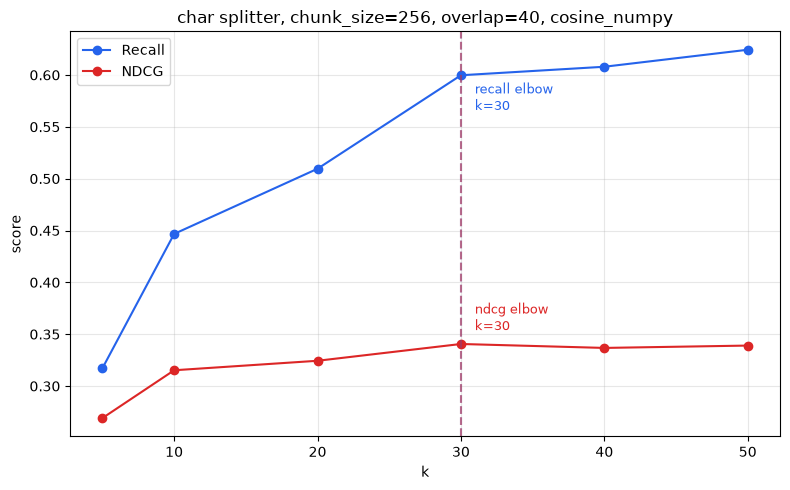

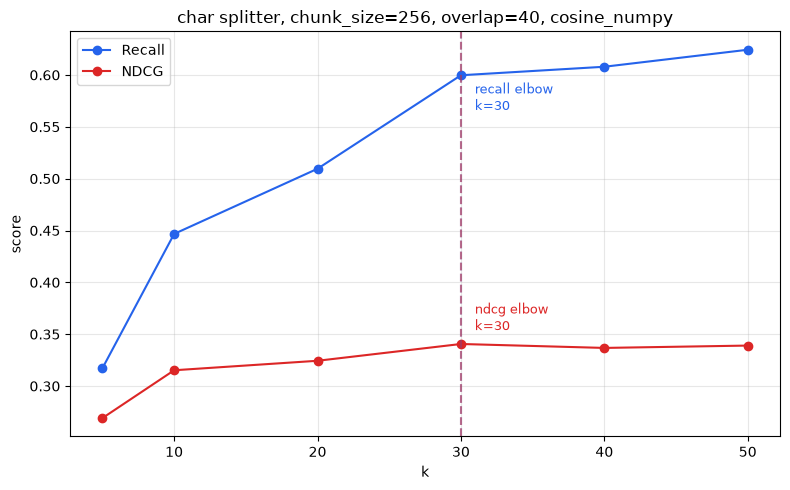

In [30]:

config_df = build_single_config_curve(
        df, splitter="char", chunk_size=256, overlap=40, retriever="cosine_numpy"
    )
print("=== Single-config curve (must be non-decreasing in recall) ===")
print(config_df.to_string(index=False))

recall_elbow = find_singleconfig_elbowk(config_df, metric="recall", capture_threshold=0.90)
ndcg_elbow = find_singleconfig_elbowk(config_df, metric="ndcg", capture_threshold=0.90)
print("\n=== Recall elbow ===")
print(recall_elbow)
print("\n=== NDCG elbow ===")
print(ndcg_elbow)

plot_elbow(config_df, recall_elbow, ndcg_elbow,
           title="char splitter, chunk_size=256, overlap=40, cosine_numpy")
